Predicting Irrigation Need

In [5]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler


def carregar_dados(caminho_treino, caminho_teste):
    """
    Carrega os conjuntos de dados de treino e teste.
    """
    print("Etapa 1: Carregando os dados...")
    if not os.path.exists(caminho_treino):
        print(f"Aviso: Arquivo {caminho_treino} não encontrado. Verifique o caminho.")
        return None, None

    train = pd.read_csv(caminho_treino)
    test = pd.read_csv(caminho_teste)
    print(f"Dados carregados. Treino: {train.shape}, Teste: {test.shape}")
    return train, test

train, test = carregar_dados('train.csv', 'test.csv')
train.head()

Etapa 1: Carregando os dados...
Dados carregados. Treino: (630000, 21), Teste: (270000, 20)


,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [7]:
def preparar_dados(train, test):
    """
    Separa as features (X) do target (y) e aplica transformacoes manuais de regras de negocio.
    """
    print("Etapa 2: Preparando features e target...")
    
    # Separação de Features e Target
    X = train.drop(columns=['id', 'Irrigation_Need'])
    y = train['Irrigation_Need']
    test_ids = test['id']
    X_test = test.drop(columns=['id'])

    # Feature Engineering Manual (Regra de Negócio)
    crop_mapping = {"Potato": 1, "Maize": 1, "Wheat": 2, "Cotton": 2, "Rice": 3, "Sugarcane": 3}
    X['Crop_Type'] = X['Crop_Type'].replace(crop_mapping)
    X_test['Crop_Type'] = X_test['Crop_Type'].replace(crop_mapping)
    
    print("Preparacao concluida.")
    return X, y, X_test, test_ids

X, y, X_test, test_ids = preparar_dados(train, test)
display(X.head())

Etapa 2: Preparando features e target...
Preparacao concluida.


/tmp/ipykernel_25222/725776793.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X['Crop_Type'] = X['Crop_Type'].replace(crop_mapping)
/tmp/ipykernel_25222/725776793.py:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_test['Crop_Type'] = X_test['Crop_Type'].replace(crop_mapping)


,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region
0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,16.79,3,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East
1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,3.39,2,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South
2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,3.85,3,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North
3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,2.31,2,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South
4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,13.94,2,Sowing,Rabi,Canal,River,7.37,No,93.19,South



--- Analisando Correlacoes e Escalonando Dados ---
Correlacao das variaveis numericas com 'Irrigation_Need':
Irrigation_Need            1.000000
Wind_Speed_kmh             0.258170
Temperature_C              0.252867
Previous_Irrigation_mm     0.019637
Field_Area_hectare         0.017699
Electrical_Conductivity    0.010785
Organic_Carbon             0.006451
Soil_pH                    0.000150
Sunlight_Hours            -0.000313
Humidity                  -0.021870
Rainfall_mm               -0.111478
Soil_Moisture             -0.455482
Name: Irrigation_Need, dtype: float64


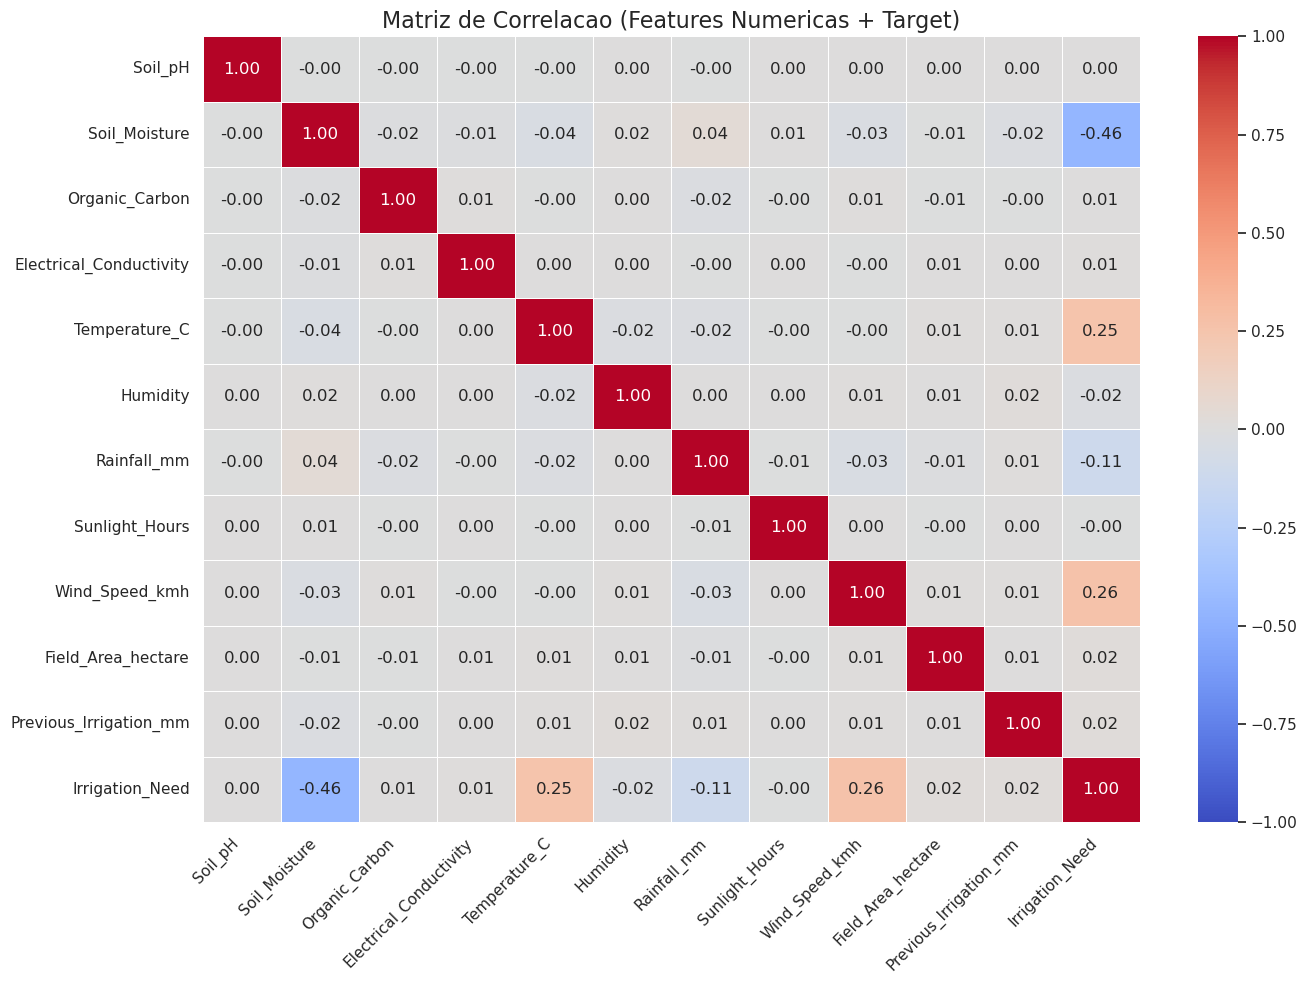


Aplicando StandardScaler explicitamente nas features numericas...


In [28]:
def escalonar_e_analisar(X, y, X_test):
    """
    Realiza o escalonamento manual das variaveis numericas e analisa as correlacoes,
    conforme solicitado para visualizacao explicita no Jupyter Notebook.
    """
    print("\n--- Analisando Correlacoes e Escalonando Dados ---")
    
    # 1. Definir as colunas numericas explicitamente
    num_cols = ['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 
                'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 
                'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm']
    
    # 2. Correlacao com o Target
    # Mapear temporariamente o target para calcular a correlacao
    mapeamento_target = {"Low": 0, "Medium": 1, "High": 2}
    y_temp = y.map(mapeamento_target)
    
    nums = X[num_cols].copy()
    nums["Irrigation_Need"] = y_temp
    
    target_corr = nums.corr()["Irrigation_Need"].sort_values(ascending=False)
    print("Correlacao das variaveis numericas com 'Irrigation_Need':")
    print(target_corr)
    
    # 3. Plotar o Heatmap de correlacao (AGORA INCLUINDO O TARGET)
    plt.figure(figsize=(14, 10))
    # Usando 'nums.corr()' para que a coluna Irrigation_Need apareca no grafico!
    sns.heatmap(nums.corr(), annot=True, fmt=".2f", cmap='coolwarm', linewidths=.5, vmin=-1, vmax=1)
    plt.title('Matriz de Correlacao (Features Numericas + Target)', fontsize=16)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # 4. Escalonamento com StandardScaler
    print("\nAplicando StandardScaler explicitamente nas features numericas...")
    ss = StandardScaler()
    
    # Aplica o fit_transform no treino e apenas transform no teste
    X[num_cols] = ss.fit_transform(X[num_cols])
    X_test[num_cols] = ss.transform(X_test[num_cols])
    
    return X, X_test

X, X_test = escalonar_e_analisar(X, y, X_test)


In [12]:
def construir_precessador(X):
    """
    Cria o ColumnTransformer que aplicará as transformações adequadas para cada tipo de coluna.
    """
    print("Etapa 3: Construindo o pre-processador (ColumnTransformer)...")
    
    soil_order = ['Clay', 'Loamy', 'Silt', 'Sandy']
    growth_order = ['Sowing', 'Harvest', 'Vegetative', 'Flowering']
    season_order = ['Kharif', 'Rabi', 'Zaid']
    mulch_order = ['Yes', 'No']

    cols_ordinais = ['Soil_Type', 'Crop_Growth_Stage', 'Season', 'Mulching_Used']
    cols_nominais = ["Water_Source", "Irrigation_Type", "Region"]
    cols_numericas = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), cols_numericas),
            ('ord', OrdinalEncoder(categories=[soil_order, growth_order, season_order, mulch_order]), cols_ordinais),
            ('nom', OneHotEncoder(drop='first', handle_unknown='ignore'), cols_nominais)
        ],
        remainder='passthrough'
    )
    
    return preprocessor


preprocessor = construir_precessador(X)




Etapa 3: Construindo o pre-processador (ColumnTransformer)...


In [9]:
def treinar_modelo(X, y, preprocessor):
    """
    Codifica o target, monta o pipeline (com oversampling) e realiza a busca de hiperparametros.
    """
    print("Etapa 4: Configurando pipeline e iniciando o treinamento...")
    
    # Codificação do Target
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)

    # Criação do Pipeline com imblearn
    pipeline = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('sampler', RandomOverSampler(random_state=42)),
        ('classifier', XGBClassifier(random_state=1, eval_metric='mlogloss', objective='multi:softprob'))
    ])

    # Hiperparâmetros para Busca
    param_grid_xgb = {
        'classifier__n_estimators': [100, 200, 300],
        'classifier__max_depth': [3, 5, 7],
        'classifier__learning_rate': [0.05, 0.1, 0.2],
        'classifier__subsample': [0.8, 1.0],
        'classifier__colsample_bytree': [0.8, 1.0]
    }

    clf_xgb = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_grid_xgb,
        n_iter=10, # Reduzido para 10 para testes mais rapidos no Jupyter
        cv=3,      # Reduzido para 3 para testes mais rapidos no Jupyter
        scoring='roc_auc_ovr',
        verbose=1,
        n_jobs=-1,
        random_state=1
    )

    print("Buscando melhores hiperparametros. Aguarde...")
    clf_xgb.fit(X, y_encoded)
    
    print("\nMelhor Score AUC: ", clf_xgb.best_score_)
    print("Melhores Parametros: ", clf_xgb.best_params_)
    
    return clf_xgb, le

modelo_otimizado, label_encoder = treinar_modelo(X, y, preprocessor)

Etapa 4: Configurando pipeline e iniciando o treinamento...
Buscando melhores hiperparametros. Aguarde...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Melhor Score AUC:  0.9974804740021693
Melhores Parametros:  {'classifier__subsample': 0.8, 'classifier__n_estimators': 300, 'classifier__max_depth': 5, 'classifier__learning_rate': 0.2, 'classifier__colsample_bytree': 1.0}


In [10]:
def gerar_submissao(modelo, le, X_test, test_ids, nome_arquivo="submission_optimized.csv"):
    """
    Realiza as previsoes nos dados de teste e exporta o CSV.
    """
    print(f"Etapa 5: Realizando previsoes e salvando em {nome_arquivo}...")
    
    predictions_encoded = modelo.predict(X_test)
    predictions_labels = le.inverse_transform(predictions_encoded)

    output = pd.DataFrame({
        "id": test_ids,
        "Irrigation_Need": predictions_labels 
    })
    
    output.to_csv(nome_arquivo, index=False)
    print("Arquivo gerado com sucesso!")

gerar_submissao(modelo_otimizado, label_encoder, X_test, test_ids)

Etapa 5: Realizando previsoes e salvando em submission_optimized.csv...
Arquivo gerado com sucesso!
